In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import QuantileTransformer
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.feature_selection import chi2
from sklearn.preprocessing import KBinsDiscretizer


from scipy.stats import pointbiserialr


In [10]:
def leer_dataset():
    df = pd.read_csv('data.csv')
    # lista de columnas a eliminar
    cols_to_drop = ['ALEAT', 'ID','VT']  # reemplaza por los nombres reales
    df = df.drop(columns=cols_to_drop)
    df.rename(columns={'V31_P': 'V31'}, inplace=True)
    df.rename(columns={'V31_P.1': 'V31_P'}, inplace=True)
    # lista de columnas a eliminar
    cols_to_drop = ['V14', 'V14_P']  

    # hacer el drop
    df = df.drop(columns=cols_to_drop)
    df['OBJ']=df['OBJ'].map({'NO':0,'SI':1})
    
    return df
def subset_datos(df):
    #Separar grupos de datos en absolutos y relativos
    absolutas=[col for col in df.columns if '_P' not in col and col != 'OBJ' and col != 'VT']
    relativas=[col for col in df.columns if '_P' in col]
    return df[absolutas], df[relativas], df['OBJ']

def plot_boxplot(df, columnas, titulo='Boxplot'):
    plt.figure(figsize=(15,6))
    sns.boxplot(data=df[columnas])
    plt.title(titulo)
    plt.xticks(rotation=90)
    plt.show()

def apply_caps(df, caps):
    df_capped = df.copy()
    for col, (lower, upper) in caps.items():
        df_capped[col] = df[col].clip(lower, upper)
    return df_capped



def cap_outliers_iqr(df, columns, factor=1.5):
    """
    Aplica un cap (winsorization) a los valores fuera del rango IQR,
    y además devuelve los límites calculados para cada columna.

    Args:
        df (pd.DataFrame): DataFrame original.
        columns (list): Lista de nombres de columnas numéricas a capar.
        factor (float): Multiplicador del IQR (default 1.5).

    Returns:
        df_capped (pd.DataFrame): DataFrame con valores capeados.
        limits_dict (dict): Diccionario con {columna: (lower, upper)}.
    """
    df_capped = df.copy()
    limits_dict = {}
    
    for col in columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - factor * iqr
        upper = q3 + factor * iqr
        # Guardar límites
        limits_dict[col] = (lower, upper)
        # Aplicar cap
        df_capped[col] = df[col].clip(lower, upper)
        
    return df_capped, limits_dict

def recalculate_relative_variables(df, absolute_columns, relative_suffix='_P', total_column='VT'):
    """
    Recalcula las variables relativas V*_P como V* / VT, donde VT es la suma de las columnas absolutas.
    
    Args:
        df (pd.DataFrame): el dataframe original.
        absolute_columns (list): lista de columnas absolutas (ej. V1, V2, V3...).
        relative_suffix (str): sufijo que se añade para las columnas relativas (default '_P').
        total_column (str): nombre de la columna de total (default 'VT').
    
    Returns:
        pd.DataFrame: dataframe con las columnas relativas recalculadas.
    """
    df_new = df.copy()
    # Calcular la suma total VT
    df_new[total_column] = df_new[absolute_columns].sum(axis=1)
    
    # Calcular las variables relativas
    for col in absolute_columns:
        perc_col = f"{col}{relative_suffix}"
        df_new[perc_col] = df_new[col] / df_new[total_column]
    
    df_new.drop(columns=absolute_columns + [total_column], inplace=True)

    
    return df_new



import pandas as pd
from scipy.stats import chi2_contingency

import pandas as pd
from scipy.stats import chi2_contingency

def chi2_analysis(X, y, bins=4, alpha=0.05):
    """
    Aplica qcut y test chi² a un dataframe de variables ya limpias (cap, etc),
    contra el target y.

    Args:
        X (pd.DataFrame): DataFrame con las variables independientes (cap, normalizadas, etc).
        y (pd.Series): Serie con la variable objetivo.
        bins (int): Número de quantiles para qcut (default 4).
        alpha (float): Nivel de significancia (default 0.05).

    Returns:
        dict con:
            - 'excluded_vars': variables sin variación suficiente
            - 'tested_vars': variables que pasaron qcut
            - 'significant_vars': variables con p < alpha
            - 'results_df': DataFrame con variable, chi2, p-value ordenado
    """
    variables_exploratorias = []
    excluidas_sin_variacion = []
    chi2_results = []

    for col in X.columns:
        try:
            bins_col = pd.qcut(X[col], q=bins, labels=False, duplicates='drop')
            n_bins = bins_col.nunique()
            if n_bins > 1:
                contingency = pd.crosstab(bins_col, y)
                chi2_stat, p_val, dof, expected = chi2_contingency(contingency)
                
                chi2_results.append({
                    'variable': col,
                    'chi2': chi2_stat,
                    'p_value': p_val
                })
                
                variables_exploratorias.append(col)
            else:
                excluidas_sin_variacion.append(col)
        except Exception:
            excluidas_sin_variacion.append(col)

    results_df = pd.DataFrame(chi2_results).sort_values(by='chi2', ascending=False).reset_index(drop=True)
    significant_vars = results_df[results_df['p_value'] < alpha]['variable'].tolist()

    return {
        'excluded_vars': excluidas_sin_variacion,
        'tested_vars': variables_exploratorias,
        'significant_vars': significant_vars,
        'results_df': results_df
    }


def point_biserial_analysis(X, y, alpha=0.05):
    """
    Calcula el coeficiente punto biserial y p-value para cada variable en X respecto a y.
    
    Args:
        X (pd.DataFrame): dataframe con variables independientes.
        y (pd.Series): vector target binario.
        alpha (float): nivel de significancia (default 0.05)
    
    Returns:
        pd.DataFrame con columnas:
            ['variable', 'r_pb', 'p_value', 'status']
            ordenado por p-value ascendente.
    """
    resultados = []
    
    for col in X.columns:
        try:
            corr, pval = pointbiserialr(y, X[col])
            status = 'Significativa' if pval < alpha else 'No significativa'
            resultados.append({
                'variable': col,
                'r_pb': corr,
                'p_value': pval,
                'status': status
            })
        except Exception as e:
            resultados.append({
                'variable': col,
                'r_pb': np.nan,
                'p_value': np.nan,
                'status': f'Error: {e}'
            })
    
    results_df = pd.DataFrame(resultados).sort_values(by='p_value', na_position='last').reset_index(drop=True)
    return results_df

def count_outliers_iqr(df, columns, factor=1.5):
    """
    Cuenta la cantidad de outliers por variable usando el criterio IQR.
    
    Args:
        df (pd.DataFrame): dataframe original.
        columns (list): lista de columnas numéricas.
        factor (float): multiplicador del IQR (default 1.5)
        
    Returns:
        pd.DataFrame con columnas ['variable', 'outliers_count', 'outliers_percent']
    """
    outliers_summary = []
    
    for col in columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - factor * iqr
        upper = q3 + factor * iqr
        
        outliers = df[(df[col] < lower) | (df[col] > upper)][col]
        count = outliers.count()
        percent = (count / len(df)) * 100
        
        outliers_summary.append({
            'variable': col,
            'outliers_count': count,
            'outliers_percent': percent
        })
        
    return pd.DataFrame(outliers_summary)
def outlier_proportion_by_target(df, columns, target, factor=1.5):
    """
    Calcula el porcentaje de outliers en cada grupo del target para cada variable.
    
    Args:
        df (pd.DataFrame): dataframe original
        columns (list): lista de columnas numéricas
        target (str): nombre de la columna target binaria
        factor (float): multiplicador del IQR (default 1.5)
        
    Returns:
        pd.DataFrame con columnas:
            ['variable', 'outliers_%_target_0', 'outliers_%_target_1', 'diff_%']
    """
    summary = []
    for col in columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - factor * iqr
        upper = q3 + factor * iqr
        
        # Para cada grupo del target
        prop_0 = df[(df[target]==0) & ((df[col]<lower) | (df[col]>upper))].shape[0] / df[df[target]==0].shape[0] * 100
        prop_1 = df[(df[target]==1) & ((df[col]<lower) | (df[col]>upper))].shape[0] / df[df[target]==1].shape[0] * 100
        
        summary.append({
            'variable': col,
            'outliers_%_target_0': prop_0,
            'outliers_%_target_1': prop_1,
            'diff_%': abs(prop_1 - prop_0)
        })
        
    return pd.DataFrame(summary).sort_values(by='diff_%', ascending=False).reset_index(drop=True)

# SPLIT DE DATOS

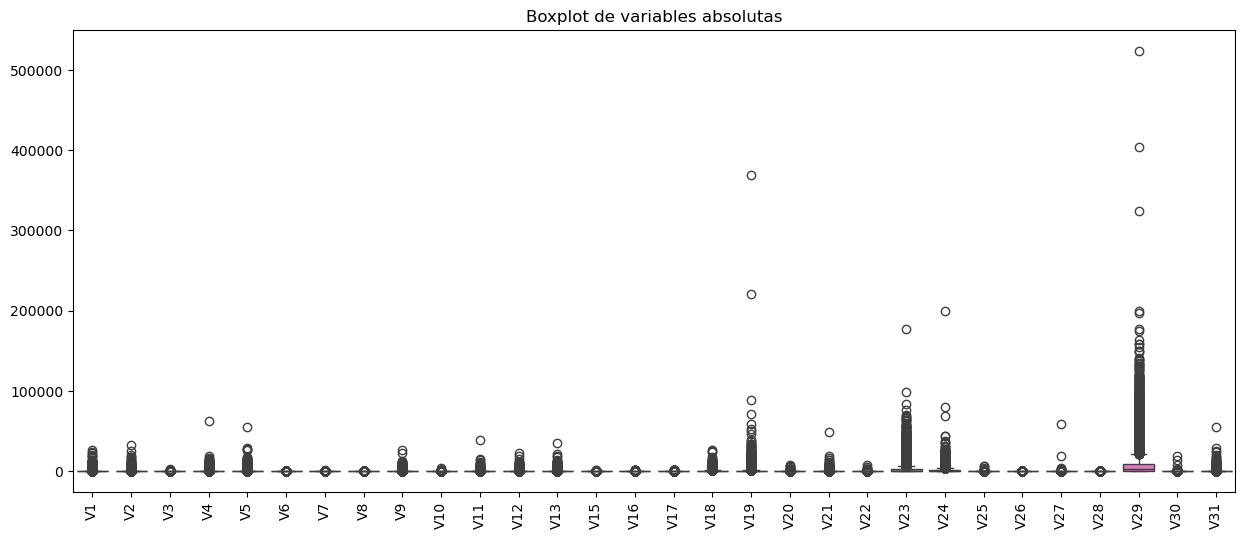

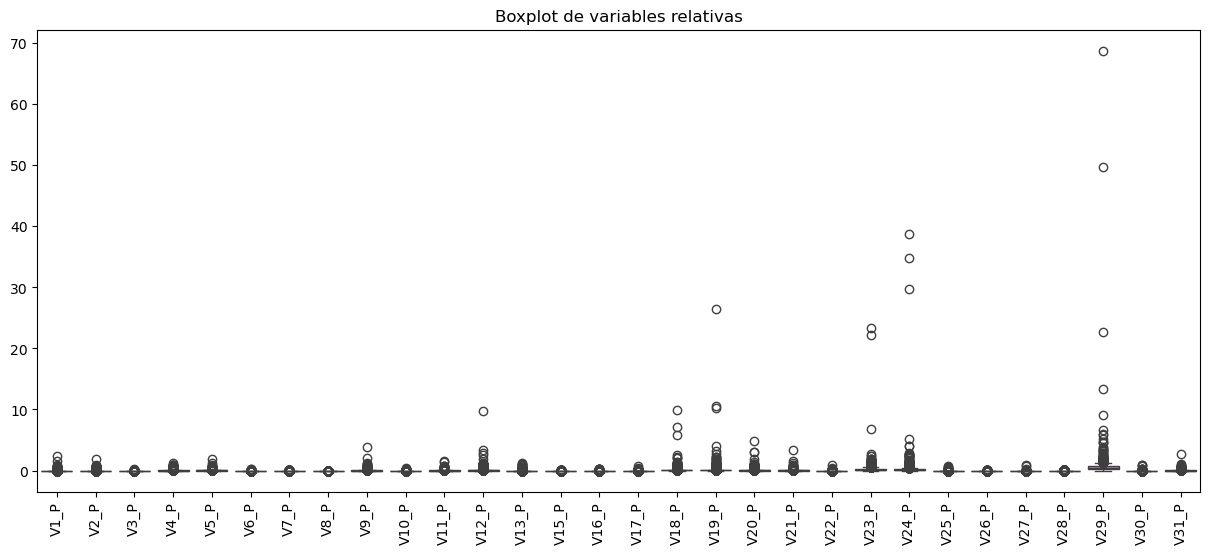

In [11]:
data= leer_dataset()
#Separar grupos de datos en absolutos y relativos
columnas_absolutas=[col for col in data.columns if '_P' not in col and col != 'OBJ' and col != 'VT']
columnas_relativas=[col for col in data.columns if '_P' in col]
#transformar variable objetivo en 1 y 0 para evitar posibles errores en modelos que no lo soporten
y=data['OBJ']  # Variable objetivo
x_abs= data[columnas_absolutas]  # Variables absolutas
x_rel= data[columnas_relativas]  # Variables relativas

x_abs_train,x_abs_test,y_abs_train,y_abs_test=train_test_split(x_abs,y,test_size=0.2,stratify=y,random_state=42)
x_rel_train,x_rel_test,y_rel_train,y_rel_test=train_test_split(x_rel,y,test_size=0.2,stratify=y,random_state=42)
#X_abs, X_rel, y = subset_datos(data)
plot_boxplot(data, columnas_absolutas, titulo='Boxplot de variables absolutas')
plot_boxplot(data, columnas_relativas, titulo='Boxplot de variables relativas')

   variable  outliers_count  outliers_percent
0        V1            2334             23.34
1        V2            1863             18.63
2        V3            1708             17.08
3        V4            1593             15.93
4        V5            1417             14.17
5        V6            1313             13.13
6        V7             514              5.14
7        V8             155              1.55
8        V9            1447             14.47
9       V10            1895             18.95
10      V11            1461             14.61
11      V12            1335             13.35
12      V13            2133             21.33
13      V15            1006             10.06
14      V16             996              9.96
15      V17            1309             13.09
16      V18            1163             11.63
17      V19            1360             13.60
18      V20             895              8.95
19      V21            1242             12.42
20      V22            1742       

C:\Users\Nicolas Oporto\AppData\Local\Temp\ipykernel_31016\461012340.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


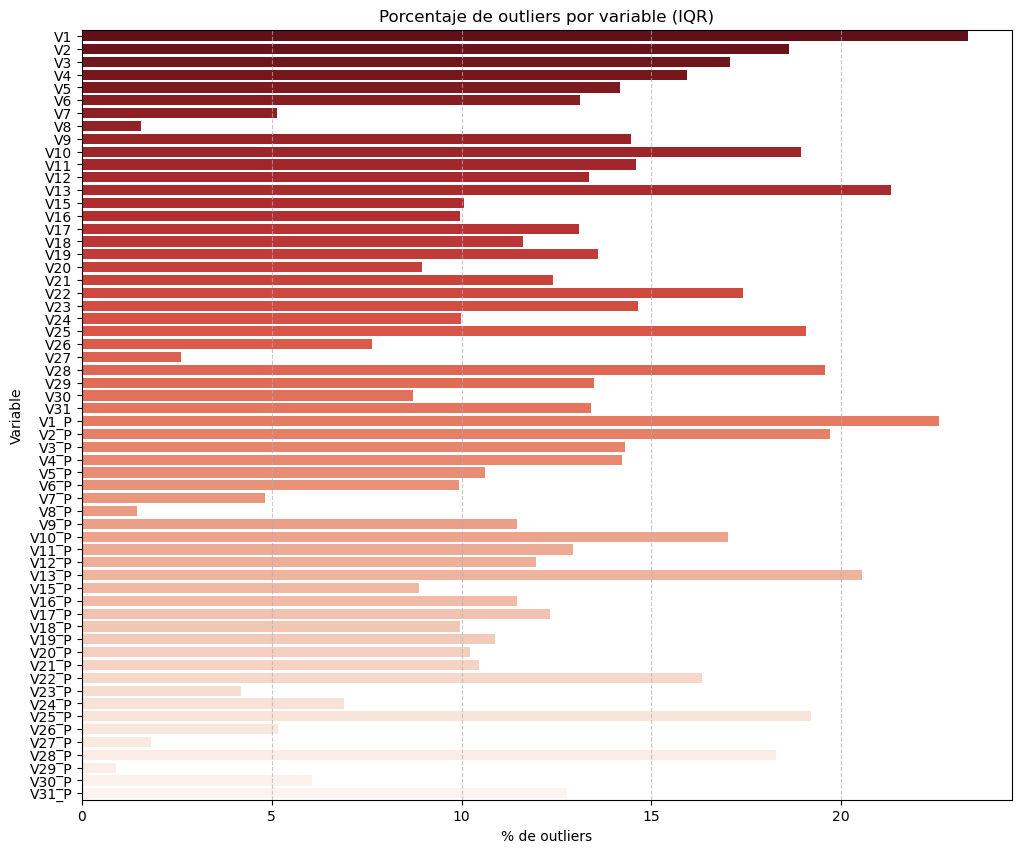

In [12]:
outliers = count_outliers_iqr(data, columnas_absolutas+columnas_relativas)
print(outliers)

plt.figure(figsize=(12,10))
sns.barplot(
    x='outliers_percent',
    y='variable',
    data=outliers,
    palette='Reds_r'
)
plt.xlabel('% de outliers')
plt.ylabel('Variable')
plt.title('Porcentaje de outliers por variable (IQR)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [7]:
outliers = outlier_proportion_by_target(
    df=data,
    columns=columnas_absolutas + columnas_relativas,
    target='OBJ',
    factor=1.5
)

print(outliers)


   variable  outliers_%_target_0  outliers_%_target_1     diff_%
0        V2            15.973445            26.116838  10.143393
1      V2_P            17.206341            26.727759   9.521418
2        V3            14.930226            23.138603   8.208376
3      V3_P            12.437339            19.625811   7.188472
4     V22_P            14.550874            21.344024   6.793151
5        V4            14.252811            20.656739   6.403928
6       V22            15.743124            22.145857   6.402733
7     V28_P            16.691505            22.756777   6.065272
8      V4_P            12.721853            18.518519   5.796665
9       V28            18.086980            23.787705   5.700725
10      V15             8.698008            13.898435   5.200426
11    V15_P             7.587048            12.485682   4.898634
12    V21_P             9.388972            13.440244   4.051273
13      V16             8.914781            12.905689   3.990908
14      V21            11

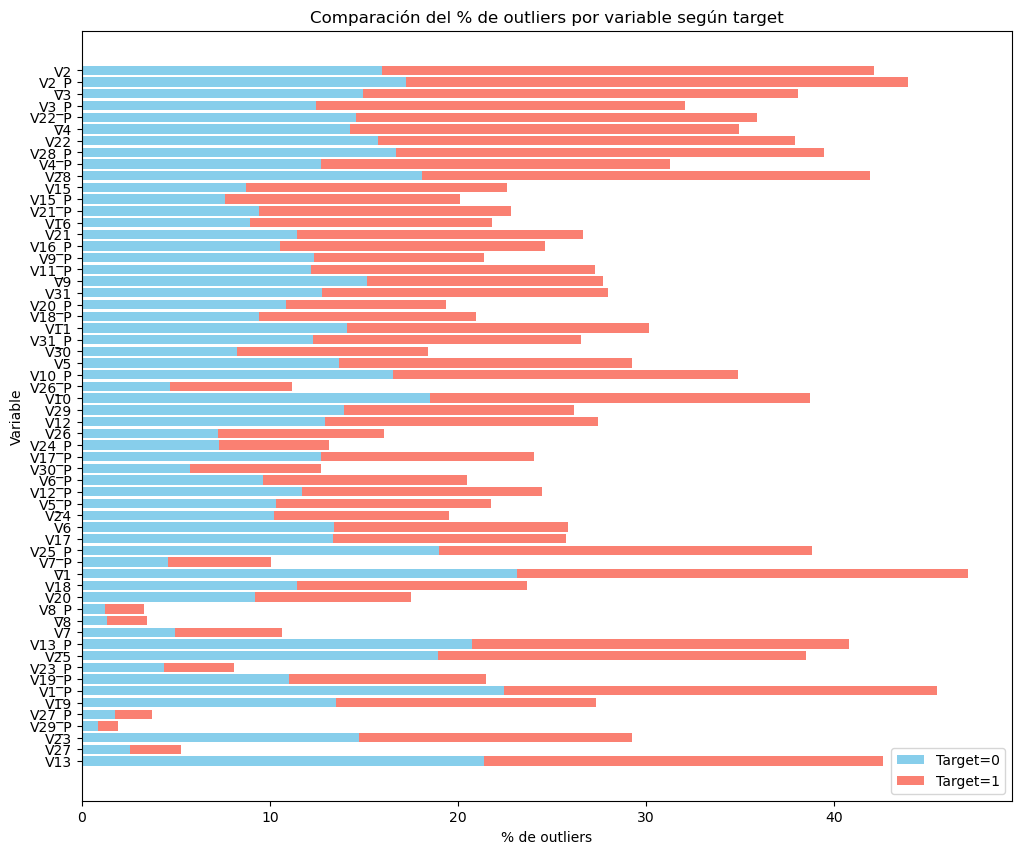

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ordenar por la diferencia descendente
outliers_by_target_sorted = outliers.sort_values(by='diff_%', ascending=False)

# Crear plot
plt.figure(figsize=(12,10))
plt.barh(outliers_by_target_sorted['variable'], 
         outliers_by_target_sorted['outliers_%_target_0'], label='Target=0', color='skyblue')
plt.barh(outliers_by_target_sorted['variable'], 
         outliers_by_target_sorted['outliers_%_target_1'], 
         left=outliers_by_target_sorted['outliers_%_target_0'], 
         label='Target=1', color='salmon')

plt.xlabel('% de outliers')
plt.ylabel('Variable')
plt.title('Comparación del % de outliers por variable según target')
plt.legend()
plt.gca().invert_yaxis()
plt.show()


No se limpiaran los outliers dado que estan presentes en gran medida en todo el dataset en consecuencia tendriamos mucha perdida de informacion, veremos como se comporta con modelos mas complejos y  en ultimo caso intentar con tratamiento de outliers para ver si el modelo se comporta mejor.

# Limpieza de outliers solo en train set

In [71]:
x_abs_train_cap,limits_cap=cap_outliers_iqr(x_abs_train, x_abs_train.columns, factor=1.5)
x_abs_test_cap=apply_caps(x_abs_test, limits_cap)
x_rel_train_cap=recalculate_relative_variables(x_abs_train_cap,columnas_absolutas, relative_suffix='_P', total_column='VT')
x_rel_test_cap=recalculate_relative_variables(x_abs_test_cap,columnas_absolutas, relative_suffix='_P', total_column='VT')

 # Feature selection (test chi² y punto biserial)

In [14]:
# ==============================================================
# 1️⃣ Crear copia temporal del dataframe para el análisis Chi²
# ==============================================================

df_temp = data.copy()
aplicaron_log = []

for col in columnas_absolutas + columnas_relativas:
    # Winsorizing al 1% y 99%
    q01 = df_temp[col].quantile(0.01)
    q99 = df_temp[col].quantile(0.99)
    df_temp[col] = df_temp[col].clip(lower=q01, upper=q99)
    
    # Log si todos los valores son positivos después del clip
    if (df_temp[col] > 0).all():
        df_temp[col] = np.log(df_temp[col])
        aplicaron_log.append(col)

print("✅ Winsorizing aplicado (1%-99%) en todas las variables.")
print("✅ Log aplicado en las siguientes variables (solo si >0):")
print(aplicaron_log)

# ==============================================================
# 2️⃣ Exploración: verificar al menos 2 bins para el Chi²
# ==============================================================

variables_candidatas = columnas_absolutas + columnas_relativas

variables_exploratorias = []
excluidas_sin_variacion = []

for col in variables_candidatas:
    try:
        bins = pd.qcut(df_temp[col], q=4, labels=False, duplicates='drop')
        n_bins = bins.nunique()
        if n_bins > 1:
            variables_exploratorias.append(col)
        else:
            excluidas_sin_variacion.append(col)
    except Exception as e:
        excluidas_sin_variacion.append(col)

print("\n❌ Variables excluidas por no tener suficiente variación (solo 1 bin):")
print(excluidas_sin_variacion)

print("\n✅ Variables que pasaron a validación Chi² (≥2 bins):")
print(variables_exploratorias)

✅ Winsorizing aplicado (1%-99%) en todas las variables.
✅ Log aplicado en las siguientes variables (solo si >0):
['V19', 'V24', 'V19_P', 'V24_P']

❌ Variables excluidas por no tener suficiente variación (solo 1 bin):
['V3', 'V7', 'V8', 'V10', 'V15', 'V26', 'V27', 'V28', 'V30', 'V3_P', 'V7_P', 'V8_P', 'V10_P', 'V15_P', 'V26_P', 'V27_P', 'V28_P', 'V30_P']

✅ Variables que pasaron a validación Chi² (≥2 bins):
['V1', 'V2', 'V4', 'V5', 'V6', 'V9', 'V11', 'V12', 'V13', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V29', 'V31', 'V1_P', 'V2_P', 'V4_P', 'V5_P', 'V6_P', 'V9_P', 'V11_P', 'V12_P', 'V13_P', 'V16_P', 'V17_P', 'V18_P', 'V19_P', 'V20_P', 'V21_P', 'V22_P', 'V23_P', 'V24_P', 'V25_P', 'V29_P', 'V31_P']


In [19]:
resultados = []

for col in variables_exploratorias:
    try:
        bins = pd.qcut(df_temp[col], q=4, labels=False, duplicates='drop')
        contingency = pd.crosstab(bins, data['OBJ'])  # importante: con OBJ original
        n_bins = bins.nunique()
        min_cell = contingency.min().min()

        # Frecuencia mínima por celda
        if min_cell < 5:
            resultados.append({
                'Variable': col,
                'Bins': n_bins,
                'Min count': min_cell,
                'Chi2': np.nan,
                'p-value': np.nan,
                'Status': f'Excluida (celda <5)'
            })
            continue

        # Aplicar Chi²
        chi2, p, dof, expected = chi2_contingency(contingency)
        status = 'Significativa' if p < 0.05 else 'No significativa'

        resultados.append({
            'Variable': col,
            'Bins': n_bins,
            'Min count': min_cell,
            'Chi2': chi2,
            'p-value': p,
            'Status': status
        })

    except Exception as e:
        resultados.append({
            'Variable': col,
            'Bins': np.nan,
            'Min count': np.nan,
            'Chi2': np.nan,
            'p-value': np.nan,
            'Status': f'Error: {e}'
        })

# Convertir a DataFrame ordenado
resultados_df = pd.DataFrame(resultados).sort_values(by='p-value', na_position='last')

# Mostrar tabla final
print("🔍 Resumen del test Chi² por variable:")
display(resultados_df)

# Variables seleccionadas para el modelo
variables_finales = resultados_df.loc[resultados_df['Status'] == 'Significativa', 'Variable'].tolist()

print("\n✅ Variables seleccionadas para el modelo final (Chi² significativas):")
print(variables_finales)


🔍 Resumen del test Chi² por variable:


,Variable,Bins,Min count,Chi2,p-value,Status
22,V2_P,3,639,131.531874,2.742941e-29,Significativa
1,V2,3,646,131.075014,3.446849e-29,Significativa
23,V4_P,4,491,133.868456,7.930891e-29,Significativa
9,V16,4,496,127.155888,2.217860e-27,Significativa
2,V4,4,477,123.737516,1.208923e-26,Significativa
35,V21_P,4,492,110.353720,9.208969e-24,Significativa
36,V22_P,3,672,105.085414,1.517024e-23,Significativa
20,V31,4,474,97.963156,4.260000e-21,Significativa
30,V16_P,4,508,96.791492,7.608035e-21,Significativa
14,V21,4,488,92.115505,7.693409e-20,Significativa



✅ Variables seleccionadas para el modelo final (Chi² significativas):
['V2_P', 'V2', 'V4_P', 'V16', 'V4', 'V21_P', 'V22_P', 'V31', 'V16_P', 'V21', 'V22', 'V19', 'V23', 'V31_P', 'V18', 'V6', 'V19_P', 'V5', 'V29', 'V11', 'V5_P', 'V6_P', 'V12', 'V20', 'V11_P', 'V13', 'V24', 'V18_P', 'V9_P', 'V9', 'V23_P', 'V17_P', 'V17', 'V24_P', 'V13_P', 'V29_P', 'V25', 'V25_P', 'V20_P', 'V12_P']


In [20]:
from scipy.stats import pointbiserialr
import numpy as np
import pandas as pd

# Combinar todas las variables (exploratorias que pasaron bins + las que no)
todas_las_variables = variables_exploratorias + excluidas_sin_variacion

# Lista para guardar resultados
resultados_pb_total = []

for col in todas_las_variables:
    try:
        corr, pval = pointbiserialr(data['OBJ'], data[col])
        status = 'Significativa' if pval < 0.05 else 'No significativa'
        
        resultados_pb_total.append({
            'Variable': col,
            'r_pb': corr,
            'p-value': pval,
            'Status': status
        })
    except Exception as e:
        resultados_pb_total.append({
            'Variable': col,
            'r_pb': np.nan,
            'p-value': np.nan,
            'Status': f'Error: {e}'
        })

# Convertir a DataFrame ordenado
resultados_pb_df_total = pd.DataFrame(resultados_pb_total).sort_values(by='p-value', na_position='last')

# Mostrar tabla
print("📊 Resultados del test punto-biserial en todas las variables:")
display(resultados_pb_df_total)


📊 Resultados del test punto-biserial en todas las variables:


,Variable,r_pb,p-value,Status
2,V4,0.057686,7.801350e-09,Significativa
22,V2_P,0.052559,1.449194e-07,Significativa
23,V4_P,0.046250,3.711102e-06,Significativa
11,V18,0.041480,3.335613e-05,Significativa
35,V21_P,0.038599,1.130080e-04,Significativa
1,V2,0.037323,1.891121e-04,Significativa
9,V16,0.035592,3.709608e-04,Significativa
49,V28,0.034582,5.426212e-04,Significativa
14,V21,0.033947,6.857541e-04,Significativa
18,V25,0.032404,1.191660e-03,Significativa


## Comparación del Chi² vs Punto Biserial

En este análisis se evaluó la asociación de cada variable independiente con la variable objetivo (`OBJ`) utilizando dos enfoques complementarios:

- **Test Chi²:** mide independencia entre categorías formadas mediante binning (qcut), adecuado para identificar diferencias en la distribución entre segmentos.
- **Correlación punto biserial:** mide la relación lineal directa entre la variable continua y la variable binaria `OBJ`.

Algunos hallazgos clave del análisis:

    Varias variables resultaron significativas según el test Chi², reflejando que su distribución discreta difiere entre las clases (por ejemplo, `V4`, `V16`, `V22`).  
    Otras variables mostraron significancia solo bajo el punto biserial (por ejemplo `V15`, `V28`), indicando que, aunque no presentan diferencias claras por bins, sí mantienen una tendencia lineal con `OBJ`.

Además, el análisis evidenció que:

- Las variables excluidas del Chi² (por no poder formar al menos 2 bins) igualmente fueron evaluadas mediante punto biserial, lo que permitió rescatar posibles relaciones lineales que de otra forma hubieran quedado descartadas.
- La comparación lado a lado permite validar la robustez de cada variable, identificando cuáles son significativas en ambos enfoques, y cuáles solo bajo una perspectiva.

Este análisis garantiza que la selección final de variables para el modelo no dependa de un único criterio estadístico, sino de una visión integral, maximizando la capacidad explicativa del conjunto de datos.

In [21]:
# -----------------------------------------------------
# 1️⃣ Preparamos el DataFrame del Chi²
# -----------------------------------------------------
df_chi = resultados_df[['Variable', 'Status', 'p-value']].rename(
    columns={'Status': 'Chi² Status', 'p-value': 'Chi² p-value'}
)

# -----------------------------------------------------
# 2️⃣ Preparamos el DataFrame del punto biserial
# -----------------------------------------------------
df_pb = resultados_pb_df_total[['Variable', 'Status', 'p-value']].rename(
    columns={'Status': 'PuntoBiserial Status', 'p-value': 'PuntoBiserial p-value'}
)

# -----------------------------------------------------
# 3️⃣ Hacemos el merge
# -----------------------------------------------------
df_comparativo = pd.merge(df_chi, df_pb, on='Variable', how='outer')

# Ordenar por nombre de variable o por Chi² p-value
df_comparativo.sort_values(by='Variable', inplace=True)

df_comparativo['Chi² Status'] = df_comparativo['Chi² Status'].fillna('No evaluada (1 bin o excluida)')


# -----------------------------------------------------
# 4️⃣ Mostrar tabla final
# -----------------------------------------------------
print("📊 Comparación del resultado del Chi² vs Punto Biserial:")
display(df_comparativo)


📊 Comparación del resultado del Chi² vs Punto Biserial:


,Variable,Chi² Status,Chi² p-value,PuntoBiserial Status,PuntoBiserial p-value
0,V1,No significativa,4.384827e-01,No significativa,2.394487e-01
1,V10,No evaluada (1 bin o excluida),NaN,No significativa,9.363011e-01
2,V10_P,No evaluada (1 bin o excluida),NaN,No significativa,3.314742e-01
3,V11,Significativa,4.935136e-12,No significativa,9.998242e-02
4,V11_P,Significativa,2.050967e-08,No significativa,1.507780e-01
5,V12,Significativa,7.787469e-11,No significativa,1.367638e-01
6,V12_P,Significativa,3.965901e-02,No significativa,2.189518e-01
7,V13,Significativa,4.483070e-08,No significativa,1.128766e-01
8,V13_P,Significativa,3.606376e-05,No significativa,1.370947e-01
9,V15,No evaluada (1 bin o excluida),NaN,Significativa,2.175373e-02


## Criterio final para selección de variables

Para la etapa de selección de variables, se aplicaron dos enfoques complementarios:

- **Test Chi²:** evalúa la independencia entre la variable categorizada (mediante binning) y la variable objetivo binaria `OBJ`.
- **Correlación punto biserial:** mide la relación lineal directa entre la variable continua y `OBJ`.

El criterio adoptado para conservar variables en el modelo fue **incluir todas aquellas que resultaron significativas en al menos uno de los dos tests**.  
De este modo, se garantiza no descartar variables que puedan aportar capacidad explicativa, ya sea por evidenciar una relación segmentada (detectada por Chi²) o una tendencia lineal (detectada por punto biserial).

Solo se eliminaron las variables que **no mostraron significancia estadística en ninguno de los dos enfoques**, asegurando así un modelo final con el máximo potencial informativo.

In [22]:
# Variables que NO pasaron ninguno de los dos tests:
# es decir, no significativas en Chi² y no significativas en punto biserial
no_significativas_ninguno = df_comparativo[
    ((df_comparativo['Chi² Status'] != 'Significativa') & 
     (df_comparativo['PuntoBiserial Status'] != 'Significativa'))
]['Variable'].tolist()

# Separar en ABS y REL
candidatas_quitar_abs = [v for v in no_significativas_ninguno if v in columnas_absolutas]
candidatas_quitar_rel = [v for v in no_significativas_ninguno if v in columnas_relativas]

print("Variables ABSOLUTAS candidatas a eliminar (no significativas en ninguno de los dos tests):")
print(candidatas_quitar_abs)

print("\nVariables PROPORCIONALES candidatas a eliminar (no significativas en ninguno de los dos tests):")
print(candidatas_quitar_rel)


Variables ABSOLUTAS candidatas a eliminar (no significativas en ninguno de los dos tests):
['V1', 'V10', 'V27', 'V30', 'V7', 'V8']

Variables PROPORCIONALES candidatas a eliminar (no significativas en ninguno de los dos tests):
['V10_P', 'V15_P', 'V1_P', 'V26_P', 'V27_P', 'V28_P', 'V30_P', 'V3_P', 'V7_P', 'V8_P']


## Análisis de multicolinealidad en variables absolutas

Para garantizar la estabilidad y la interpretabilidad del modelo, se evaluó la multicolinealidad entre las variables absolutas mediante la matriz de correlación de Pearson.

- Se construyó una matriz de correlación absoluta (`corr().abs()`), extrayendo únicamente el triángulo superior para evitar duplicados.
- Se revisaron todas las parejas de variables, utilizando un umbral de **0.90** para identificar posibles redundancias.

El análisis evidenció que **no existieron pares de variables con correlación superior a 0.90**, por lo que no fue necesario eliminar ninguna variable en esta etapa.  
Esto confirma que el conjunto de variables absolutas no presenta problemas de colinealidad alta y puede ser utilizado en el modelo sin riesgo de inestabilidad numérica asociada a variables redundantes.

In [25]:
# ============================================
# BLOQUE PARA ABSOLUTOS
# ============================================
# Calcular matriz de correlación absoluta
corr_matrix_abs = x_abs.corr().abs()

# Extraer triángulo superior para evitar duplicados
upper_abs = corr_matrix_abs.where(np.triu(np.ones(corr_matrix_abs.shape), k=1).astype(bool))

# Buscar variables con correlación mayor a 0.90
to_drop_abs_corr = [column for column in upper_abs.columns if any(upper_abs[column] > 0.90)]

print("Variables ABSOLUTAS a eliminar por alta correlación (>0.90):", to_drop_abs_corr)

# Eliminar del dataset
X_abs_reduced = x_abs.drop(columns=to_drop_abs_corr)

print("Shape original ABS:", x_abs.shape)
print("Shape reducido ABS:", X_abs_reduced.shape)


# ============================================
# BLOQUE PARA RELATIVOS
# ============================================
# Calcular matriz de correlación
corr_matrix_p = x_rel.corr().abs()

# Triángulo superior
upper_p = corr_matrix_p.where(np.triu(np.ones(corr_matrix_p.shape), k=1).astype(bool))

# Buscar variables con correlación mayor a 0.90
to_drop_p_corr = [column for column in upper_p.columns if any(upper_p[column] > 0.90)]

print("Variables PROPORCIONALES a eliminar por alta correlación (>0.90):", to_drop_p_corr)

# Eliminar del dataset
X_p_reduced = x_rel.drop(columns=to_drop_p_corr)

print("Shape original PROP:", x_rel.shape)
print("Shape reducido PROP:", X_p_reduced.shape)

Variables ABSOLUTAS a eliminar por alta correlación (>0.90): []
Shape original ABS: (10000, 30)
Shape reducido ABS: (10000, 30)
Variables PROPORCIONALES a eliminar por alta correlación (>0.90): []
Shape original PROP: (10000, 30)
Shape reducido PROP: (10000, 30)


In [13]:
import numpy as np
X_abs = df[columnas_absolutas]
X_p = df[columnas_relativas]
# ============================================
# BLOQUE PARA ABSOLUTOS
# ============================================
# Calcular matriz de correlación absoluta
corr_matrix_abs = X_abs.corr().abs()

# Extraer triángulo superior para evitar duplicados
upper_abs = corr_matrix_abs.where(np.triu(np.ones(corr_matrix_abs.shape), k=1).astype(bool))

# Buscar variables con correlación mayor a 0.90
to_drop_abs_corr = [column for column in upper_abs.columns if any(upper_abs[column] > 0.90)]

print("Variables ABSOLUTAS a eliminar por alta correlación (>0.90):", to_drop_abs_corr)

# Eliminar del dataset
X_abs_reduced = X_abs.drop(columns=to_drop_abs_corr)

print("Shape original ABS:", X_abs.shape)
print("Shape reducido ABS:", X_abs_reduced.shape)

# ============================================
# BLOQUE PARA RELATIVOS
# ============================================
# Calcular matriz de correlación
corr_matrix_p = X_p.corr().abs()

# Triángulo superior
upper_p = corr_matrix_p.where(np.triu(np.ones(corr_matrix_p.shape), k=1).astype(bool))

# Buscar variables con correlación mayor a 0.90
to_drop_p_corr = [column for column in upper_p.columns if any(upper_p[column] > 0.90)]

print("Variables PROPORCIONALES a eliminar por alta correlación (>0.90):", to_drop_p_corr)

# Eliminar del dataset
X_p_reduced = X_p.drop(columns=to_drop_p_corr)

print("Shape original PROP:", X_p.shape)
print("Shape reducido PROP:", X_p_reduced.shape)


Variables ABSOLUTAS a eliminar por alta correlación (>0.90): []
Shape original ABS: (10000, 30)
Shape reducido ABS: (10000, 30)
Variables PROPORCIONALES a eliminar por alta correlación (>0.90): []
Shape original PROP: (10000, 30)
Shape reducido PROP: (10000, 30)


# Declarar variables con las que se va trabajar

In [26]:
# =====================================
# LIBRERÍAS BÁSICAS
# =====================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

# =====================================
# DEFINIR VARIABLES SEGÚN TU DATA
# columnas_absolutas y columnas_relativas deben estar ya definidos:
# Ejemplo:
# columnas_absolutas = ['V1', 'V2', ..., 'V30']
# columnas_relativas = ['V1_P', 'V2_P', ..., 'V30_P']
# =====================================
y=data['OBJ']  # Variable objetivo
x= data[columnas_absolutas + columnas_relativas]
x_trained,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)  # Todas las variables
# =====================================
# DATA ABSOLUTA
# =====================================
# DATA ORIGINAL
X_abs = data[columnas_absolutas]

# DATA FILTRADA (sin variables no significativas ni altamente correlacionadas)
X_abs_filtered = X_abs.drop(columns=list(set(candidatas_quitar_abs + to_drop_abs_corr)))

# Dividir en train/test
X_abs_train, X_abs_test, y_abs_train, y_abs_test = train_test_split(
    X_abs, y, test_size=0.2, stratify=y, random_state=42
)
X_abs_f_train, X_abs_f_test, y_abs_f_train, y_abs_f_test = train_test_split(
    X_abs_filtered, y, test_size=0.2, stratify=y, random_state=42
)

# =====================================
# DATA RELATIVA
# =====================================
# DATA ORIGINAL
X_p = data[columnas_relativas]

# DATA FILTRADA
X_p_filtered = X_p.drop(columns=list(set(candidatas_quitar_rel + to_drop_p_corr)))

# Dividir en train/test
X_p_train, X_p_test, y_p_train, y_p_test = train_test_split(
    X_p, y, test_size=0.2, stratify=y, random_state=42
)
X_p_f_train, X_p_f_test, y_p_f_train, y_p_f_test = train_test_split(
    X_p_filtered, y, test_size=0.2, stratify=y, random_state=42
)


In [32]:
y=data['OBJ']  # Variable objetivo
x= data[columnas_absolutas + columnas_relativas]
x_abs= data[columnas_absolutas]
x_abs_filtered= data[columnas_absolutas].drop(columns=list(set(candidatas_quitar_abs + to_drop_abs_corr)))
x_rel= data[columnas_relativas]
x_rel_filtered= data[columnas_relativas].drop(columns=list(set(candidatas_quitar_rel + to_drop_p_corr)))

In [56]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    x_rel_filtered, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


# Random Forest

In [57]:
from imblearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import QuantileTransformer
from imblearn.combine import SMOTEENN
from sklearn.model_selection import GridSearchCV

# Pipeline RF
pipe_rf = Pipeline([
    ('scaler', QuantileTransformer(output_distribution='normal', random_state=42)),
    ('sampler', SMOTEENN()),
    ('model', RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1))
])

# Grid RF
param_grid_rf = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [10, 20],
    'model__min_samples_split': [5],
    'model__min_samples_leaf': [3]
}

grid_rf = GridSearchCV(
    estimator=pipe_rf,
    param_grid=param_grid_rf,
    scoring='balanced_accuracy',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_


Fitting 5 folds for each of 4 candidates, totalling 20 fits


# Logistic Regression

In [58]:
from sklearn.linear_model import LogisticRegression

pipe_logit = Pipeline([
    ('scaler', QuantileTransformer(output_distribution='normal', random_state=42)),
    ('sampler', SMOTEENN()),
    ('model', LogisticRegression(class_weight='balanced', solver='liblinear', random_state=42))
])

param_grid_logit = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__penalty': ['l1', 'l2']
}

grid_logit = GridSearchCV(
    estimator=pipe_logit,
    param_grid=param_grid_logit,
    scoring='balanced_accuracy',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_logit.fit(X_train, y_train)
best_logit = grid_logit.best_estimator_


Fitting 5 folds for each of 8 candidates, totalling 40 fits


# XGBoost

In [ ]:
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline
from imblearn.combine import SMOTEENN
from sklearn.preprocessing import QuantileTransformer
from sklearn.model_selection import GridSearchCV

# Pipeline con XGB
pipe_xgb = Pipeline([
    ('scaler', QuantileTransformer(output_distribution='normal', random_state=42)),
    ('sampler', SMOTEENN()),
    ('model', XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
])

# Param grid con tus mejores params
param_grid_xgb = {
    'model__n_estimators': [500],
    'model__max_depth': [9],
    'model__learning_rate': [0.01],
    'model__subsample': [0.8],
    'model__colsample_bytree': [1.0],
    'model__scale_pos_weight': [1]
}

# GridSearch
grid_xgb = GridSearchCV(
    estimator=pipe_xgb,
    param_grid=param_grid_xgb,
    scoring='balanced_accuracy',
    cv=5,
    n_jobs=-1,
    verbose=2
)
grid_xgb.fit(X_train, y_train)
best_xgb = grid_xgb.best_estimator_

# SVM

In [ ]:
from sklearn.svm import SVC
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import QuantileTransformer
from imblearn.combine import SMOTEENN
from sklearn.model_selection import GridSearchCV

# Pipeline con SVM
pipe_svm = Pipeline([
    ('scaler', QuantileTransformer(output_distribution='normal', random_state=42)),
    ('sampler', SMOTEENN()),
    ('model', SVC(probability=True, random_state=42))
])

# Param grid con tus mejores parámetros fijos
param_grid_svm = {
    'model__C': [1],
    'model__kernel': ['rbf'],
    'model__class_weight': ['balanced']
}

# GridSearch
grid_svm = GridSearchCV(
    estimator=pipe_svm,
    param_grid=param_grid_svm,
    scoring='balanced_accuracy',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_svm.fit(X_train, y_train)
best_svm = grid_svm.best_estimator_

print(f"\n✅ Best Params (SVM): {grid_svm.best_params_}")
print(f"✅ CV balanced_accuracy: {grid_svm.best_score_:.4f}")


# Hard Voting- Modelo de ensamble

In [61]:
from sklearn.ensemble import VotingClassifier

ensemble = VotingClassifier(
    estimators=[
        ('rf', best_rf),
        ('logit', best_logit),
        ('xgb', best_xgb),
        ('svm', best_svm)
    ],
    voting='soft',  # usa las probabilidades
    n_jobs=-1
)

# Entrenamos sobre el train
ensemble.fit(X_train, y_train)

# Evaluamos en el test
from sklearn.metrics import classification_report, confusion_matrix

y_pred_ens = ensemble.predict(X_test)
print("\n📊 Classification Report (Ensemble):")
print(classification_report(y_test, y_pred_ens))

cm_ens = confusion_matrix(y_test, y_pred_ens)
print("\nConfusion Matrix (Ensemble):")
print(cm_ens)



📊 Classification Report (Ensemble):
              precision    recall  f1-score   support

           0       0.81      0.40      0.54      1476
           1       0.30      0.73      0.43       524

    accuracy                           0.49      2000
   macro avg       0.56      0.57      0.48      2000
weighted avg       0.68      0.49      0.51      2000


Confusion Matrix (Ensemble):
[[590 886]
 [139 385]]


# Hard voting con pesos en los modelos

In [68]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import precision_score, recall_score, f1_score
import itertools
import pandas as pd

# ==========================
# GENERAR TODAS LAS COMBINACIONES DE PESOS
# ==========================
weight_grid = list(itertools.product([1,2,3], repeat=4))
results = []

# ==========================
# LOOP SOBRE TODAS LAS COMBINACIONES
# ==========================
for w in weight_grid:
    ensemble = VotingClassifier(
        estimators=[
            ('rf', best_rf),
            ('logit', best_logit),
            ('xgb', best_xgb),
            ('svm', best_svm)
        ],
        voting='hard',
        weights=w,
        n_jobs=-1
    )
    
    # Entrenamos sobre el train
    ensemble.fit(X_train, y_train)
    
    # Predecimos en el test
    y_pred = ensemble.predict(X_test)
    
    # Calculamos métricas
    rec = recall_score(y_test, y_pred, zero_division=0)
    prec = precision_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    # Guardamos resultados
    results.append({
        'weights': w,
        'recall': rec,
        'precision': prec,
        'f1': f1
    })

# ==========================
# MOSTRAR LOS MEJORES RESULTADOS
# ==========================
df_results = pd.DataFrame(results)
df_sorted = df_results.sort_values(by='f1', ascending=False)

print("\n📊 Top combinaciones de pesos según F1:")
print(df_sorted.head(10))


KeyboardInterrupt: 

# Satcking Classifier- Modelo de ensmable

In [64]:
from sklearn.ensemble import StackingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Stacking con probabilities y XGBoost como meta-modelo
stacking = StackingClassifier(
    estimators=[
        ('rf', best_rf),
        ('logit', best_logit),
        ('xgb', best_xgb),
        ('svm', best_svm)
    ],
    final_estimator=XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ),
    cv=5,
    stack_method='predict_proba',
    n_jobs=-1
)

# Entrenamos el stacking
stacking.fit(X_train, y_train)

# Evaluación en test
y_pred_stack = stacking.predict(X_test)

print("\n📊 Classification Report (Stacking - proba + XGB):")
print(classification_report(y_test, y_pred_stack))

cm_stack = confusion_matrix(y_test, y_pred_stack)
print("\nConfusion Matrix (Stacking - proba + XGB):")
print(cm_stack)



📊 Classification Report (Stacking - proba + XGB):
              precision    recall  f1-score   support

           0       0.74      0.93      0.83      1476
           1       0.32      0.09      0.14       524

    accuracy                           0.71      2000
   macro avg       0.53      0.51      0.48      2000
weighted avg       0.63      0.71      0.65      2000


Confusion Matrix (Stacking - proba + XGB):
[[1379   97]
 [ 478   46]]


In [65]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

import pandas as pd

# ================================
# PROBABILIDADES DEL STACKING
# ================================
y_proba_stack = stacking.predict_proba(X_test)[:,1]

# Umbrales a probar
thresholds = [0.3, 0.4, 0.5, 0.6]

# Guardar resultados
threshold_results = []

for threshold in thresholds:
    y_pred_thresh = (y_proba_stack >= threshold).astype(int)
    
    # Calcular métricas
    prec = precision_score(y_test, y_pred_thresh, zero_division=0)
    rec = recall_score(y_test, y_pred_thresh, zero_division=0)
    f1 = f1_score(y_test, y_pred_thresh, zero_division=0)
    
    cm = confusion_matrix(y_test, y_pred_thresh)
    
    # Mostrar resultados en consola
    print(f"\n=== Threshold: {threshold} ===")
    print(f"Precision: {prec:.3f} | Recall: {rec:.3f} | F1: {f1:.3f}")
    print("Confusion Matrix:")
    print(cm)
    
    # Guardar en lista
    threshold_results.append({
        'Threshold': threshold,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'TN': cm[0,0],
        'FP': cm[0,1],
        'FN': cm[1,0],
        'TP': cm[1,1]
    })

# Convertir a DataFrame para analizar mejor
df_thresholds = pd.DataFrame(threshold_results)
print("\n📊 Summary of thresholds:")
print(df_thresholds)



=== Threshold: 0.3 ===
Precision: 0.328 | Recall: 0.399 | F1: 0.360
Confusion Matrix:
[[1047  429]
 [ 315  209]]

=== Threshold: 0.4 ===
Precision: 0.353 | Recall: 0.216 | F1: 0.268
Confusion Matrix:
[[1269  207]
 [ 411  113]]

=== Threshold: 0.5 ===
Precision: 0.322 | Recall: 0.088 | F1: 0.138
Confusion Matrix:
[[1379   97]
 [ 478   46]]

=== Threshold: 0.6 ===
Precision: 0.411 | Recall: 0.044 | F1: 0.079
Confusion Matrix:
[[1443   33]
 [ 501   23]]

📊 Summary of thresholds:
   Threshold  Precision    Recall        F1    TN   FP   FN   TP
0        0.3   0.327586  0.398855  0.359725  1047  429  315  209
1        0.4   0.353125  0.215649  0.267773  1269  207  411  113
2        0.5   0.321678  0.087786  0.137931  1379   97  478   46
3        0.6   0.410714  0.043893  0.079310  1443   33  501   23


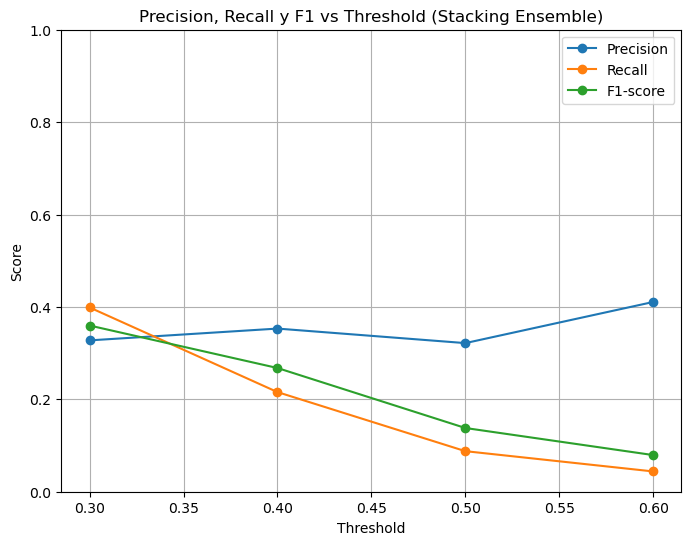

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.plot(df_thresholds['Threshold'], df_thresholds['Precision'], marker='o', label='Precision')
plt.plot(df_thresholds['Threshold'], df_thresholds['Recall'], marker='o', label='Recall')
plt.plot(df_thresholds['Threshold'], df_thresholds['F1'], marker='o', label='F1-score')

plt.title("Precision, Recall y F1 vs Threshold (Stacking Ensemble)")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.ylim(0,1)
plt.legend()
plt.grid(True)
plt.show()


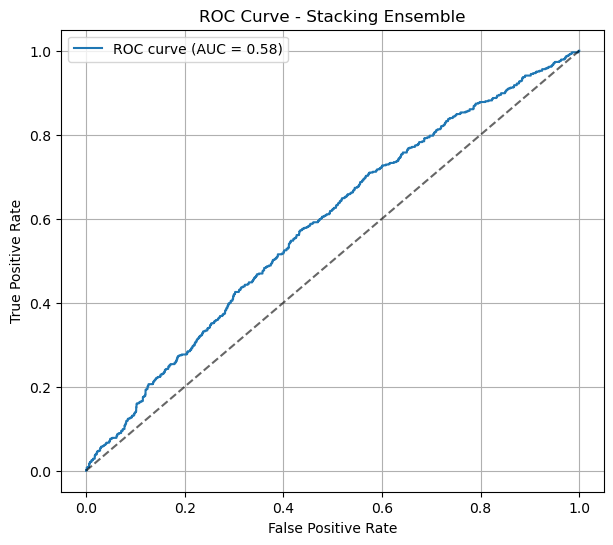

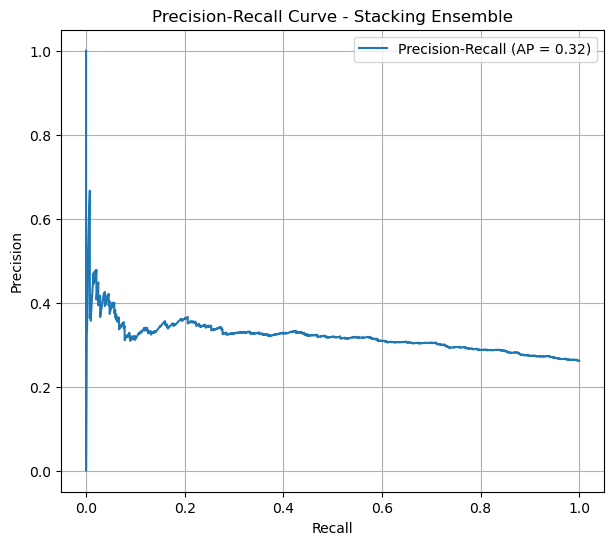

In [67]:
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score

# ============================
# ROC Curve
# ============================
auc = roc_auc_score(y_test, y_proba_stack)
fpr, tpr, _ = roc_curve(y_test, y_proba_stack)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.2f})')
plt.plot([0,1], [0,1], 'k--', alpha=0.6)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Stacking Ensemble')
plt.legend()
plt.grid(True)
plt.show()

# ============================
# Precision-Recall Curve
# ============================
prec, rec, _ = precision_recall_curve(y_test, y_proba_stack)
avg_prec = average_precision_score(y_test, y_proba_stack)

plt.figure(figsize=(7,6))
plt.plot(rec, prec, label=f'Precision-Recall (AP = {avg_prec:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Stacking Ensemble')
plt.legend()
plt.grid(True)
plt.show()



Fitting 5 folds for each of 1 candidates, totalling 5 fits


Fitting 5 folds for each of 1 candidates, totalling 5 fits

✅ Best Params (SVM): {'model__C': 1, 'model__class_weight': 'balanced', 'model__kernel': 'rbf'}
✅ CV balanced_accuracy: 0.5742


Fitting 5 folds for each of 1 candidates, totalling 5 fits

✅ CV balanced_accuracy mean: 0.5767

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.50      0.64      7381
           1       0.36      0.81      0.50      2619

    accuracy                           0.58     10000
   macro avg       0.62      0.65      0.57     10000
weighted avg       0.75      0.58      0.60     10000


Confusion Matrix:
[[3664 3717]
 [ 490 2129]]


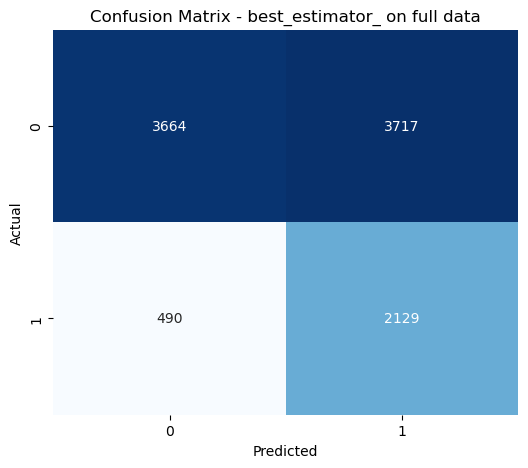

In [47]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import QuantileTransformer
from imblearn.combine import SMOTEENN

# ==============================
# SELECCIONA TU DATASET
# ==============================
X_dataset = x_abs_filtered  # o x, x_abs, x_rel, x_rel_filtered
y_dataset = y

# ==============================
# PIPELINE CON RANDOM FOREST
# ==============================
pipe_random_forest = Pipeline([
    ('scaler', QuantileTransformer(output_distribution='normal', random_state=42)),
    ('sampler', SMOTEENN()),
    ('model', RandomForestClassifier(
        class_weight='balanced',
        max_depth=10,
        min_samples_leaf=3,
        min_samples_split=5,
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

# ==============================
# GRIDSEARCH SOBRE TODA LA DATA
# ==============================
param_grid = {}
grid = GridSearchCV(
    estimator=pipe_random_forest,
    param_grid=param_grid,
    cv=5,
    scoring='balanced_accuracy',
    n_jobs=-1,
    verbose=2
)
grid.fit(X_dataset, y_dataset)

print(f"\n✅ CV balanced_accuracy mean: {grid.best_score_:.4f}")

# ==============================
# MATRIZ DE CONFUSIÓN USANDO TODA LA DATA
# ==============================
y_pred = grid.best_estimator_.predict(X_dataset)

print("\n📊 Classification Report:")
print(classification_report(y_dataset, y_pred))

cm_rf = confusion_matrix(y_dataset, y_pred)
print("\nConfusion Matrix:")
print(cm_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - best_estimator_ on full data")
plt.show()



📊 Classification Report (threshold=0.5):
              precision    recall  f1-score   support

           0       0.88      0.50      0.64      7381
           1       0.36      0.81      0.50      2619

    accuracy                           0.58     10000
   macro avg       0.62      0.65      0.57     10000
weighted avg       0.75      0.58      0.60     10000


Confusion Matrix:
[[3664 3717]
 [ 490 2129]]


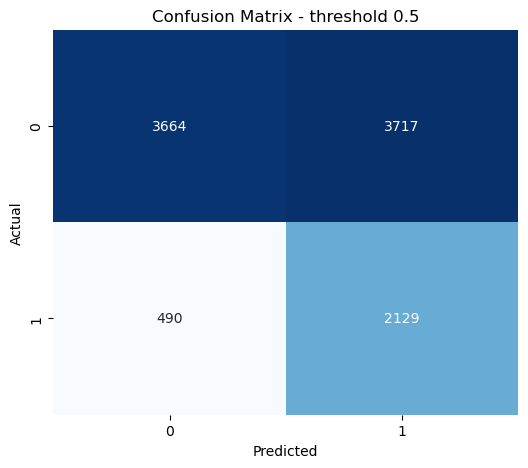


🔥 ROC-AUC: 0.7239


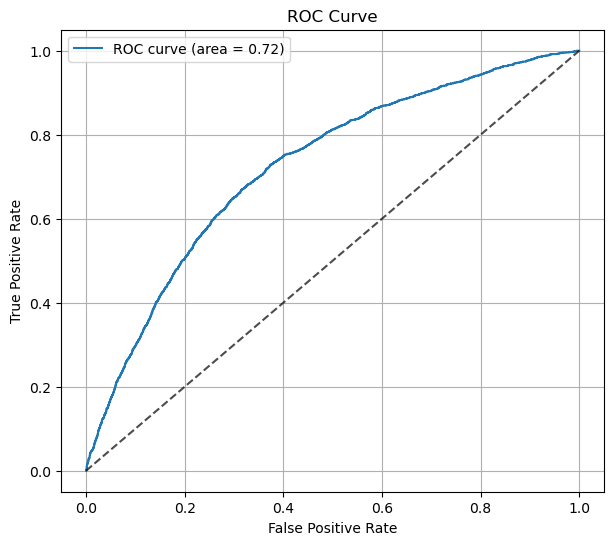

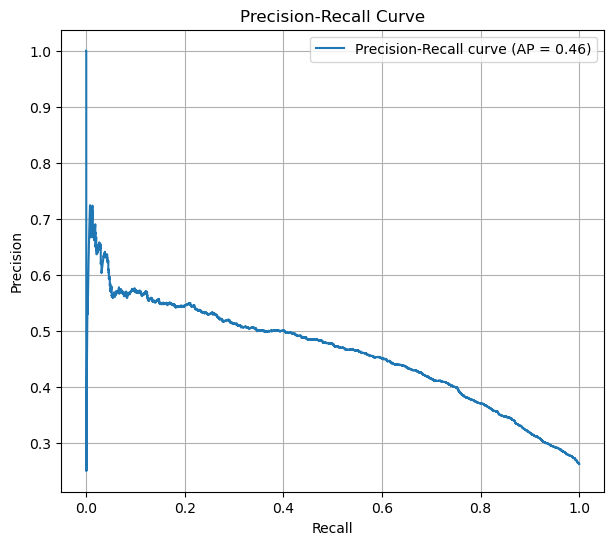

In [51]:
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, average_precision_score

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# ===========================
# PREDICCIONES PROBABILISTICAS
# ===========================
y_proba = grid.best_estimator_.predict_proba(X_dataset)[:,1]

# Puedes cambiar esto
threshold = 0.5
y_pred_thresh = (y_proba >= threshold).astype(int)

# ===========================
# NUEVO REPORT
# ===========================
print(f"\n📊 Classification Report (threshold={threshold}):")
print(classification_report(y_dataset, y_pred_thresh))

cm_rf = confusion_matrix(y_dataset, y_pred_thresh)
print("\nConfusion Matrix:")
print(cm_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - threshold {threshold}")
plt.show()

# ===========================
# ROC AUC Y CURVA
# ===========================
auc = roc_auc_score(y_dataset, y_proba)
print(f"\n🔥 ROC-AUC: {auc:.4f}")

fpr, tpr, thresholds = roc_curve(y_dataset, y_proba)
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f"ROC curve (area = {auc:.2f})")
plt.plot([0,1], [0,1], 'k--', alpha=0.7)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

# ===========================
# PRECISION-RECALL CURVE
# ===========================
prec, rec, _ = precision_recall_curve(y_dataset, y_proba)
avg_prec = average_precision_score(y_dataset, y_proba)

plt.figure(figsize=(7,6))
plt.plot(rec, prec, label=f"Precision-Recall curve (AP = {avg_prec:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()

{}


Fitting 5 folds for each of 1 candidates, totalling 5 fits

✅ CV balanced_accuracy mean: 0.5840

📊 Classification Report con threshold ajustado:
              precision    recall  f1-score   support

           0       0.80      0.57      0.66      1476
           1       0.33      0.60      0.42       524

    accuracy                           0.57      2000
   macro avg       0.56      0.58      0.54      2000
weighted avg       0.67      0.57      0.60      2000


Confusion Matrix:
[[837 639]
 [212 312]]


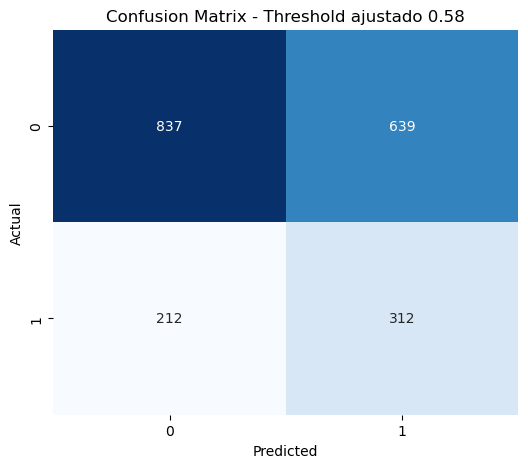

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import QuantileTransformer
from imblearn.combine import SMOTEENN

# ==============================
# PIPELINE CON PARAMS FIJOS
# ==============================
pipe_random_forest = Pipeline([
    ('scaler', QuantileTransformer(output_distribution='normal', random_state=42)),
    ('sampler', SMOTEENN()),
    ('model', RandomForestClassifier(
        class_weight='balanced',
        max_depth=10,
        min_samples_leaf=3,
        min_samples_split=5,
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

# ==============================
# GRIDSEARCH CON CROSS-VAL Y SCORING BALANCED ACCURACY
# ==============================
param_grid = {}  # no cambias nada, solo valida
grid = GridSearchCV(
    estimator=pipe_random_forest,
    param_grid=param_grid,
    cv=5,
    scoring='balanced_accuracy',
    n_jobs=-1,
    verbose=2
)
grid.fit(x_rel_filtered,y_rel_train)

print(f"\n✅ CV balanced_accuracy mean: {grid.best_score_:.4f}")

# ==============================
# EVALUACIÓN EN TEST
# ==============================
y_proba = grid.predict_proba(X_p_f_test)[:,1]
threshold = 0.58
y_pred_thresh = (y_proba >= threshold).astype(int)

print("\n📊 Classification Report con threshold ajustado:")
print(classification_report(y_p_f_test, y_pred_thresh))

cm_rf   = confusion_matrix(y_p_f_test, y_pred_thresh)
print("\nConfusion Matrix:")
print(cm_rf )

plt.figure(figsize=(6,5))
sns.heatmap(cm_rf , annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Threshold ajustado 0.58")
plt.show()


Fitting 5 folds for each of 1 candidates, totalling 5 fits

✅ CV balanced_accuracy mean: 0.5724

📊 Classification Report con threshold ajustado:
              precision    recall  f1-score   support

           0       0.78      0.58      0.67      1476
           1       0.32      0.55      0.40       524

    accuracy                           0.57      2000
   macro avg       0.55      0.56      0.54      2000
weighted avg       0.66      0.57      0.60      2000


Confusion Matrix:
[[861 615]
 [238 286]]


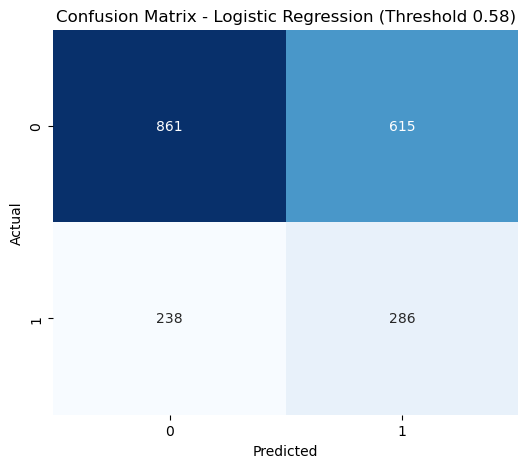

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import QuantileTransformer
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================
# PIPELINE CON LOGISTIC REGRESSION
# =========================================
pipe_logistic = Pipeline([
    ('scaler', QuantileTransformer(output_distribution='normal', random_state=42)),
    ('sampler', SMOTEENN()),
    ('model', LogisticRegression(
        C=0.1,
        penalty='l1',
        solver='saga',
        class_weight='balanced',
        random_state=42,
        max_iter=1000
    ))
])

# =========================================
# GRIDSEARCH PARA VALIDAR balanced_accuracy CON CV=5
# =========================================
param_grid = {}  # no cambia nada, solo valida config fija
grid = GridSearchCV(
    estimator=pipe_logistic,
    param_grid=param_grid,
    cv=5,
    scoring='balanced_accuracy',
    n_jobs=-1,
    verbose=2
)
grid.fit(x_rel, y_absy_train)

print(f"\n✅ CV balanced_accuracy mean: {grid.best_score_:.4f}")

# =========================================
# EVALUACIÓN EN TEST
# =========================================
y_proba = grid.predict_proba(X_abs_test)[:,1]
threshold = 0.55
y_pred_thresh = (y_proba >= threshold).astype(int)

print("\n📊 Classification Report con threshold ajustado:")
print(classification_report(y_abs_test, y_pred_thresh))

cm_lr = confusion_matrix(y_abs_test, y_pred_thresh)
print("\nConfusion Matrix:")
print(cm_lr)

plt.figure(figsize=(6,5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression (Threshold 0.58)")
plt.show()


In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.preprocessing import QuantileTransformer
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix

# ==============================
# PIPELINE CON XGBOOST
# ==============================
pipe_xgb = Pipeline([
    ('scaler', QuantileTransformer(output_distribution='normal', random_state=42)),
    ('sampler', SMOTEENN()),
    ('model', XGBClassifier(
        scale_pos_weight=1,  # ajusta según tu dataset si quieres
        max_depth=5,
        learning_rate=0.1,
        n_estimators=100,
        subsample=0.8,
        colsample_bytree=0.8,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
])

# ==============================
# VALIDACIÓN CON CROSS-VAL
# ==============================
param_grid = {
    'model__n_estimators': [100, 200, 500],
    'model__max_depth': [3, 5, 7, 9],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__subsample': [0.6, 0.8, 1.0],
    'model__colsample_bytree': [0.6, 0.8, 1.0],
    'model__scale_pos_weight': [1, 2, 3]  # para desbalance
}  # solo valida esa configuración
grid = GridSearchCV(
    estimator=pipe_xgb,
    param_grid=param_grid,
    cv=5,
    scoring='balanced_accuracy',
    n_jobs=-1,
    verbose=2
)
grid.fit(X_abs_train, y_abs_train)

print(f"\n✅ CV balanced_accuracy mean: {grid.best_score_:.4f}")

# ==============================
# EVALUACIÓN EN TEST CON THRESHOLD
# ==============================
y_proba = grid.predict_proba(X_abs_test)[:,1]

thresholds = np.linspace(0, 1, 101)
recall_0_list, recall_1_list, balanced_acc_list = [], [], []

for thr in thresholds:
    y_pred_thr = (y_proba >= thr).astype(int)
    cm_xgb  = confusion_matrix(y_abs_test, y_pred_thr)
    TN, FP, FN, TP = cm_xgb.ravel()
    recall_0 = TN / (TN + FP) if (TN + FP) > 0 else 0
    recall_1 = TP / (TP + FN) if (TP + FN) > 0 else 0
    balanced_acc = (recall_0 + recall_1) / 2
    recall_0_list.append(recall_0)
    recall_1_list.append(recall_1)
    balanced_acc_list.append(balanced_acc)

# ==============================
# PLOT
# ==============================
plt.figure(figsize=(10,6))
plt.plot(thresholds, recall_0_list, '--', label='Specificity (Recall 0)')
plt.plot(thresholds, recall_1_list, '-', label='Sensitivity (Recall 1)')
plt.plot(thresholds, balanced_acc_list, linewidth=2, label='Balanced Accuracy')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Balanced Accuracy vs Threshold (XGBoost)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# ==============================
# MEJOR THRESHOLD Y METRICAS
# ==============================
best_idx = np.argmax(balanced_acc_list)
best_thr = thresholds[best_idx]
best_bal_acc = balanced_acc_list[best_idx]

print(f"\n✅ Mejor threshold: {best_thr:.2f}")
print(f"Balanced Accuracy óptima: {best_bal_acc:.3f}")

y_pred_best = (y_proba >= best_thr).astype(int)
cm_xgb_best  = confusion_matrix(y_abs_test, y_pred_best)
print("\nConfusion Matrix en threshold óptimo:")
print(cm_xgb_best )
print("\nClassification Report:")
print(classification_report(y_abs_test, y_pred_best))

plt.figure(figsize=(6,5))
sns.heatmap(cm_xgb_best, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression (Threshold 0.58)")
plt.show()


Fitting 5 folds for each of 1296 candidates, totalling 6480 fits


KeyboardInterrupt: 

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.preprocessing import QuantileTransformer
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report

# =========================================
# LISTA DE DATASETS x_trained,x_test,y_train,y_test
# =========================================
datasets = [
    ("ORIG", x_trained, y_train, x_test, y_test),
    ("ABS ORIG", X_abs_train, y_abs_train, X_abs_test, y_abs_test),
    ("ABS FILT", X_abs_f_train, y_abs_f_train, X_abs_f_test, y_abs_f_test),
    ("PROP ORIG", X_p_train, y_p_train, X_p_test, y_p_test),
    ("PROP FILT", X_p_f_train, y_p_f_train, X_p_f_test, y_p_f_test)
]

# =========================================
# DATAFRAME PARA CONSOLIDAR RESULTADOS
# =========================================
results_list = []

for name, X_tr, y_tr, X_te, y_te in datasets:
    print(f"\n🚀 Procesando dataset: {name}")
    
    # ============================
    # PIPELINE
    # ============================
    pipe_xgb = Pipeline([
        ('scaler', QuantileTransformer(output_distribution='normal', random_state=42)),
        ('sampler', SMOTEENN()),
        ('model', XGBClassifier(
            scale_pos_weight=1,
            max_depth=5,
            learning_rate=0.1,
            n_estimators=100,
            subsample=0.8,
            colsample_bytree=0.8,
            use_label_encoder=False,
            eval_metric='logloss',
            random_state=42,
            n_jobs=-1
        ))
    ])
    
    # ============================
    # FIT CON CV
    # ============================
    grid = GridSearchCV(
        estimator=pipe_xgb,
        param_grid={},
        cv=5,
        scoring='balanced_accuracy',
        n_jobs=-1,
        verbose=0
    )
    grid.fit(X_tr, y_tr)
    cv_score = grid.best_score_
    
    # ============================
    # THRESHOLD TUNING
    # ============================
    y_proba = grid.predict_proba(X_te)[:,1]
    thresholds = np.linspace(0, 1, 101)
    
    recall_0_list, recall_1_list, balanced_acc_list = [], [], []
    for thr in thresholds:
        y_pred_thr = (y_proba >= thr).astype(int)
        cm = confusion_matrix(y_te, y_pred_thr)
        TN, FP, FN, TP = cm.ravel()
        recall_0 = TN / (TN + FP) if (TN + FP) > 0 else 0
        recall_1 = TP / (TP + FN) if (TP + FN) > 0 else 0
        balanced_acc = (recall_0 + recall_1) / 2
        recall_0_list.append(recall_0)
        recall_1_list.append(recall_1)
        balanced_acc_list.append(balanced_acc)
    
    best_idx = np.argmax(balanced_acc_list)
    best_thr = thresholds[best_idx]
    best_bal_acc = balanced_acc_list[best_idx]
    
    # ============================
    # REPORT FINAL
    # ============================
    y_pred_best = (y_proba >= best_thr).astype(int)
    cm_best = confusion_matrix(y_te, y_pred_best)
    report = classification_report(y_te, y_pred_best, output_dict=True)
    
    print(f"✅ Mejor threshold: {best_thr:.2f}")
    print(f"Balanced Accuracy óptima: {best_bal_acc:.3f}")
    print(f"Confusion Matrix:\n{cm_best}")
    
    # ============================
    # GUARDAR EN LISTA
    # ============================
    results_list.append({
        'Dataset': name,
        'CV_balanced_acc': cv_score,
        'Best_threshold': best_thr,
        'Balanced_acc_test': best_bal_acc,
        'Recall_0': report['0']['recall'],
        'Recall_1': report['1']['recall'],
        'Precision_0': report['0']['precision'],
        'Precision_1': report['1']['precision'],
        'F1_0': report['0']['f1-score'],
        'F1_1': report['1']['f1-score'],
        'Confusion_Matrix': cm_best
    })

# =========================================
# CONSOLIDAR EN DATAFRAME
# =========================================
df_results = pd.DataFrame(results_list)
print("\n📊 Comparativo final:")
display(df_results)



🚀 Procesando dataset: ORIG
✅ Mejor threshold: 0.78
Balanced Accuracy óptima: 0.577
Confusion Matrix:
[[1085  391]
 [ 304  220]]

🚀 Procesando dataset: ABS ORIG
✅ Mejor threshold: 0.67
Balanced Accuracy óptima: 0.570
Confusion Matrix:
[[874 602]
 [237 287]]

🚀 Procesando dataset: ABS FILT
✅ Mejor threshold: 0.83
Balanced Accuracy óptima: 0.578
Confusion Matrix:
[[1072  404]
 [ 299  225]]

🚀 Procesando dataset: PROP ORIG
✅ Mejor threshold: 0.57
Balanced Accuracy óptima: 0.568
Confusion Matrix:
[[710 766]
 [181 343]]

🚀 Procesando dataset: PROP FILT
✅ Mejor threshold: 0.68
Balanced Accuracy óptima: 0.582
Confusion Matrix:
[[819 657]
 [205 319]]

📊 Comparativo final:


,Dataset,CV_balanced_acc,Best_threshold,Balanced_acc_test,Recall_0,Recall_1,Precision_0,Precision_1,F1_0,F1_1,Confusion_Matrix
0,ORIG,0.581780,0.78,0.577471,0.735095,0.419847,0.781138,0.360065,0.757417,0.387665,"[[1085, 391], [304, 220]]"
1,ABS ORIG,0.570441,0.67,0.569925,0.592141,0.547710,0.786679,0.322835,0.675686,0.406228,"[[874, 602], [237, 287]]"
2,ABS FILT,0.569660,0.83,0.577838,0.726287,0.429389,0.781911,0.357711,0.753073,0.390286,"[[1072, 404], [299, 225]]"
3,PROP ORIG,0.568926,0.57,0.567805,0.481030,0.654580,0.796857,0.309288,0.599916,0.420086,"[[710, 766], [181, 343]]"
4,PROP FILT,0.564249,0.68,0.581828,0.554878,0.608779,0.799805,0.326844,0.655200,0.425333,"[[819, 657], [205, 319]]"
